# Project 3 - Global Heat Exposure: Cooling Degree Days Above 65°F (1950–2022)

## Introduction

Extreme heat has become one of the most visible and harmful consequences of climate change.  
To understand how heat exposure has evolved globally, I analyze a climate indicator called  
**Cooling Degree Days above 65°F (CDD65)**, which measures the cumulative number of degrees  
by which the daily mean temperature exceeded 65°F in a given year.

Higher CDD65 values imply higher heat exposure and greater demand for cooling systems.  
By examining long-term CDD65 patterns across countries, regions, and income groups,  
we can explore whether the warming experienced around the world has been **equally distributed**,  
or whether certain places have faced disproportionate increases in heat exposure.

### Dataset(s) to be used:
- **Cooling Degree Days above 65°F (CDD65)** from the  
  [World Bank Climate Change Knowledge Portal (CCKP)](https://data360.worldbank.org/en/indicator/WB_CCKP_CDD65?view=datatable)
- **World Bank Country Metadata** (via API)  
  https://api.worldbank.org/v2/country?format=json&per_page=400

### Analysis question:
How has global heat exposure (measured by Cooling Degree Days above 65°F) changed from 1950–2022, and how do these trends differ across regions, income groups, and countries?

### Columns that will (likely) be used:
From CDD dataset:
- `REF_AREA` (ISO3 country code)
- `year`
- `cdd65` (Cooling Degree Days above 65°F)

From World Bank metadata:
- `country_name`
- `region`
- `income_group`

### Columns to be used to merge/join:
- CDD dataset: `REF_AREA`
- Metadata dataset: `REF_AREA`

### Hypothesis:
I expect Cooling Degree Days to increase globally over time, with the steepest rises occurring in hotter regions and in low-income countries.  
I also hypothesize that low-income and lower-middle-income countries will have the highest CDD values, reflecting geographic and climatic vulnerability.

## Step 1 — Load the Cooling Degree Days (CDD65°F) Dataset

The main dataset for this project comes from the World Bank’s *Climate Change Knowledge Portal*  
and contains annual **Cooling Degree Days above 65°F (CDD65)** for ~236 economies.  
Each row represents a country or economy, and each column from 1950–2022 represents one year.

In this step, I load the dataset into a pandas DataFrame and preview its structure to verify  
that the file was read correctly and to understand what the raw data looks like before cleaning.

In [3]:
import pandas as pd

# Load the wide-format Cooling Degree Days dataset
cdd_wide = pd.read_csv("WB_CCKP_CDD65_WIDEF.csv")

# Preview the first few rows
cdd_wide.head()

,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,AGG_METHOD,AGG_METHOD_LABEL,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,A,Annual,ABW,Aruba,WB_CCKP_CDD65,Cumulative number of degrees that daily averag...,F,Degrees Fahrenheit (Â°F),MEAN,Mean,...,5548.91,5436.58,5519.96,5722.92,5664.81,5369.25,5579.93,5785.67,5562.43,5526.63
1,A,Annual,AFG,Afghanistan,WB_CCKP_CDD65,Cumulative number of degrees that daily averag...,F,Degrees Fahrenheit (Â°F),MEAN,Mean,...,1978.38,1901.84,1930.62,2016.64,2105.61,2011.68,1984.51,1855.27,2110.84,2012.76
2,A,Annual,AGO,Angola,WB_CCKP_CDD65,Cumulative number of degrees that daily averag...,F,Degrees Fahrenheit (Â°F),MEAN,Mean,...,2697.13,2706.99,2966.50,3043.80,2868.57,2946.79,3253.30,2897.56,2848.82,2662.93
3,A,Annual,AIA,Anguilla,WB_CCKP_CDD65,Cumulative number of degrees that daily averag...,F,Degrees Fahrenheit (Â°F),MEAN,Mean,...,5095.46,5088.04,5260.92,5325.00,5215.18,5058.35,5255.22,5374.73,5241.47,5170.11
4,A,Annual,ALB,Albania,WB_CCKP_CDD65,Cumulative number of degrees that daily averag...,F,Degrees Fahrenheit (Â°F),MEAN,Mean,...,692.98,521.28,885.16,685.89,877.65,723.39,841.74,776.43,883.93,904.17


## Step 2 — Inspecting the Dataset

Before reshaping or cleaning the data, I examine the structure of the raw DataFrame.  
This helps me understand:

- What each column represents  
- Which columns contain the actual CDD65 values  
- Whether the year columns are stored as numbers or strings  
- Whether there are missing values  
- How metadata columns (e.g., country names, ISO3 codes) are organized  

Because this dataset is in **wide format**, each year (1950–2022) appears as a separate column.  
I also use `.info()` to check the data types and confirm that the dataset loaded correctly.

In [4]:
cdd_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 91 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FREQ                236 non-null    object 
 1   FREQ_LABEL          236 non-null    object 
 2   REF_AREA            236 non-null    object 
 3   REF_AREA_LABEL      236 non-null    object 
 4   INDICATOR           236 non-null    object 
 5   INDICATOR_LABEL     236 non-null    object 
 6   UNIT_MEASURE        236 non-null    object 
 7   UNIT_MEASURE_LABEL  236 non-null    object 
 8   AGG_METHOD          236 non-null    object 
 9   AGG_METHOD_LABEL    236 non-null    object 
 10  DATABASE_ID         236 non-null    object 
 11  DATABASE_ID_LABEL   236 non-null    object 
 12  UNIT_MULT           236 non-null    int64  
 13  UNIT_MULT_LABEL     236 non-null    object 
 14  OBS_STATUS          236 non-null    object 
 15  OBS_STATUS_LABEL    236 non-null    object 
 16  OBS_CONF

In [5]:
cdd_wide.columns.tolist()

['FREQ',
 'FREQ_LABEL',
 'REF_AREA',
 'REF_AREA_LABEL',
 'INDICATOR',
 'INDICATOR_LABEL',
 'UNIT_MEASURE',
 'UNIT_MEASURE_LABEL',
 'AGG_METHOD',
 'AGG_METHOD_LABEL',
 'DATABASE_ID',
 'DATABASE_ID_LABEL',
 'UNIT_MULT',
 'UNIT_MULT_LABEL',
 'OBS_STATUS',
 'OBS_STATUS_LABEL',
 'OBS_CONF',
 'OBS_CONF_LABEL',
 '1950',
 '1951',
 '1952',
 '1953',
 '1954',
 '1955',
 '1956',
 '1957',
 '1958',
 '1959',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022']

In [6]:
# Identify all year columns (strings between 1950 and 2022 in the dataset)
year_cols = [
    col for col in cdd_wide.columns if col.isdigit() and 1950 <= int(col) <= 2022
]

year_cols[:10], len(year_cols)

(['1950',
  '1951',
  '1952',
  '1953',
  '1954',
  '1955',
  '1956',
  '1957',
  '1958',
  '1959'],
 73)

From the `.info()` and column inspection, I observe that:

1. **The dataset contains 236 rows**, each representing a country or economy.  
   This matches the expected global coverage of the CCKP dataset.

2. The file includes **17 metadata columns**, such as `REF_AREA` (ISO3 code),  
   `REF_AREA_LABEL` (country name), `UNIT_MEASURE`, and `INDICATOR`.  
   These describe the dataset but are not part of the heat-exposure values themselves.

3. All year columns from **1950 to 2022** were successfully identified (73 years total).  
   These columns store the actual **Cooling Degree Days above 65°F (CDD65)** values.

4. The year columns are stored as **float64**.  
   This is expected because:
   - Climate values often contain decimals  
   - Any missing values (`NaN`) force the dtype to float  

5. The dataset is in **wide format**, meaning each year is a separate column.  
   While this is common for climate data, it is not convenient for analysis.  
   To create time series plots, merge metadata, or calculate changes across years,  
   the dataset needs to be reshaped into a **long format**, where each row corresponds  
   to one country-year pair.

This understanding sets up the next step, where I reshape the dataset from  
wide to long format to prepare it for analysis.

## Step 3 — Reshaping the Dataset (Wide → Long Format)

The original CDD65 dataset is in **wide format**, meaning each year appears as a separate  
column (1950, 1951, 1952, …, 2022). While this format is convenient for spreadsheets,  
it is not ideal for analysis in pandas.

To analyze trends over time and merge with metadata, I convert the dataset into  
a **long (tidy) format**, where each row corresponds to one country–year pair:

| REF_AREA | Country | Year | CDD65 |
|----------|---------|------|-------|

This makes it much easier to group by region, create time-series plots, and calculate  
changes across years.

In [7]:
# Step 3: Reshape from wide to long format

# We already identified year_cols in Step 2
# year_cols = [col for col in cdd_wide.columns if col.isdigit() and 1950 <= int(col) <= 2022]

# Select only ID columns + year columns
cdd_subset = cdd_wide[["REF_AREA", "REF_AREA_LABEL"] + year_cols]

# Melt wide → long
cdd_long = cdd_subset.melt(
    id_vars=["REF_AREA", "REF_AREA_LABEL"],
    value_vars=year_cols,
    var_name="year",
    value_name="cdd65",
)

# Convert types
cdd_long["year"] = cdd_long["year"].astype(int)
cdd_long["cdd65"] = pd.to_numeric(cdd_long["cdd65"], errors="coerce")

# Drop any rows without values
cdd_long = cdd_long.dropna(subset=["cdd65"])

cdd_long.head()

,REF_AREA,REF_AREA_LABEL,year,cdd65
0,ABW,Aruba,1950,4877.32
1,AFG,Afghanistan,1950,1504.26
2,AGO,Angola,1950,1861.67
3,AIA,Anguilla,1950,4589.31
4,ALB,Albania,1950,939.95


## Step 4 — Adding Region and Income Group Metadata

The CDD65 dataset contains only ISO3 country codes (`REF_AREA`) and CDD degree
values. To understand regional or income-group patterns, we need to bring in 
external metadata.

The World Bank offers a public API endpoint that includes each economy’s:

- Country name  
- Region  
- Income group  

However, the API also returns several *aggregate* entries (e.g., “Africa Eastern 
and Southern”, “Europe & Central Asia”), which do not correspond to individual 
countries. These must be filtered out before merging.

Below, I clean the metadata and merge it into the long CDD dataset.

### 4.1 Retrieve metadata from the World Bank API  
The Cooling Degree Days dataset only contains ISO3 country codes.  
To analyze trends by region or income group, I first pull country metadata directly from the World Bank API.

In [8]:
import requests
import pandas as pd

# Download metadata from the World Bank Country API
url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
response = requests.get(url)
raw = response.json()

# Convert JSON to DataFrame (the actual data is in raw[1])
meta_raw = pd.json_normalize(raw[1])

meta_raw.head()

,id,iso2Code,name,capitalCity,longitude,latitude,region.id,region.iso2code,region.value,adminregion.id,adminregion.iso2code,adminregion.value,incomeLevel.id,incomeLevel.iso2code,incomeLevel.value,lendingType.id,lendingType.iso2code,lendingType.value
0,ABW,AW,Aruba,Oranjestad,-70.0167,12.5167,LCN,ZJ,Latin America & Caribbean,,,,HIC,XD,High income,LNX,XX,Not classified
1,AFE,ZH,Africa Eastern and Southern,,,,NA,NA,Aggregates,,,,NA,NA,Aggregates,,,Aggregates
2,AFG,AF,Afghanistan,Kabul,69.1761,34.5228,MEA,ZQ,"Middle East, North Africa, Afghanistan & Pakistan",MNA,XQ,"Middle East, North Africa, Afghanistan & Pakis...",LIC,XM,Low income,IDX,XI,IDA
3,AFR,A9,Africa,,,,NA,NA,Aggregates,,,,NA,NA,Aggregates,,,Aggregates
4,AFW,ZI,Africa Western and Central,,,,NA,NA,Aggregates,,,,NA,NA,Aggregates,,,Aggregates


### 4.2 Select and rename relevant metadata fields  
From the full metadata, I keep only the ISO3 code, country name, region, and income group, and rename them to match the CDD dataset.

In [9]:
meta = meta_raw[["id", "name", "region.value", "incomeLevel.value"]].rename(
    columns={
        "id": "REF_AREA",
        "name": "country_name",
        "region.value": "region",
        "incomeLevel.value": "income_group",
    }
)

meta.head()

,REF_AREA,country_name,region,income_group
0,ABW,Aruba,Latin America & Caribbean,High income
1,AFE,Africa Eastern and Southern,Aggregates,Aggregates
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFR,Africa,Aggregates,Aggregates
4,AFW,Africa Western and Central,Aggregates,Aggregates


### 4.3 Remove aggregate entries  
The API includes aggregates such as “Africa Eastern and Southern”, which do not correspond to individual countries.  
I remove these before merging.

In [10]:
meta_clean = meta[
    (meta["region"] != "Aggregates") & (meta["income_group"] != "Aggregates")
]

meta_clean.head(), meta_clean.shape

(  REF_AREA country_name                                             region  \
 0      ABW        Aruba                         Latin America & Caribbean    
 2      AFG  Afghanistan  Middle East, North Africa, Afghanistan & Pakistan   
 5      AGO       Angola                                Sub-Saharan Africa    
 6      ALB      Albania                              Europe & Central Asia   
 7      AND      Andorra                              Europe & Central Asia   
 
           income_group  
 0          High income  
 2           Low income  
 5  Lower middle income  
 6  Upper middle income  
 7          High income  ,
 (217, 4))

### 4.4 Merge metadata into the CDD dataset  
Now I merge the cleaned metadata with the long-format CDD dataset using the ISO3 country code (`REF_AREA`).

In [11]:
cdd_merged = cdd_long.merge(meta_clean, on="REF_AREA", how="left")
cdd_merged.head()

,REF_AREA,REF_AREA_LABEL,year,cdd65,country_name,region,income_group
0,ABW,Aruba,1950,4877.32,Aruba,Latin America & Caribbean,High income
1,AFG,Afghanistan,1950,1504.26,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
2,AGO,Angola,1950,1861.67,Angola,Sub-Saharan Africa,Lower middle income
3,AIA,Anguilla,1950,4589.31,NaN,NaN,NaN
4,ALB,Albania,1950,939.95,Albania,Europe & Central Asia,Upper middle income


### 4.5 Validate the merge  
A small number of countries may not have complete metadata (e.g., territories).  
I check how many rows are missing region or income information.

In [12]:
cdd_merged["region"].isna().sum(), cdd_merged["income_group"].isna().sum()

(np.int64(1679), np.int64(1679))

## Step 5 — Adding Region and Income Group Metadata

### 5.1 Global trend of Cooling Degree Days (1950–2022)

Before comparing regions or income groups, I first look at the global average 
trend in Cooling Degree Days (CDD65°F). This gives a high-level view of how 
heat exposure has evolved over the past 70+ years.

Cooling Degree Days represent how much heat accumulates above 65°F, which 
relates to demand for cooling and heat stress. The expectation is that global 
CDD should rise over time as the planet warms.

In [17]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 50.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 52.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 23.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


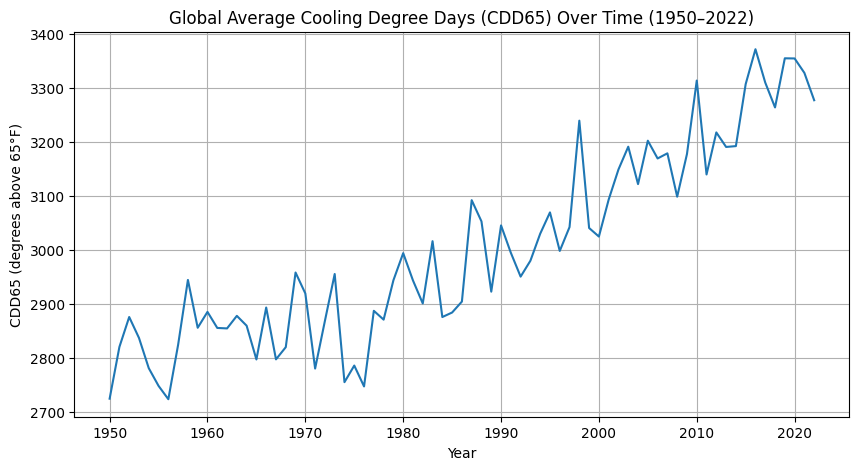

In [13]:
import matplotlib.pyplot as plt

# Compute global average per year
global_trend = cdd_merged.groupby("year")["cdd65"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(global_trend["year"], global_trend["cdd65"])
plt.title("Global Average Cooling Degree Days (CDD65) Over Time (1950–2022)")
plt.xlabel("Year")
plt.ylabel("CDD65 (degrees above 65°F)")
plt.grid(True)
plt.show()

#### Global trend analysis

The global average Cooling Degree Days (CDD65) shows a clear long-term upward 
trend from 1950 to 2022. In the early 1950s, the global average was around 
2,750–2,900 CDD. By the 2000s, it consistently exceeded 3,000, and in recent 
years it approaches or surpasses 3,300.

Although annual fluctuations exist—likely due to climate variability and 
El Niño/La Niña events—the long-term pattern is unmistakably rising.  
This indicates that the world is experiencing more accumulated heat above 65°F, 
implying greater reliance on cooling, increasing energy demand, and heightened 
heat-related risks. 

### 5.2 Regional trends

Next, I compare trends by geographic region (as defined by the World Bank).  
This helps identify which parts of the world are experiencing the fastest 
increase in heat exposure.

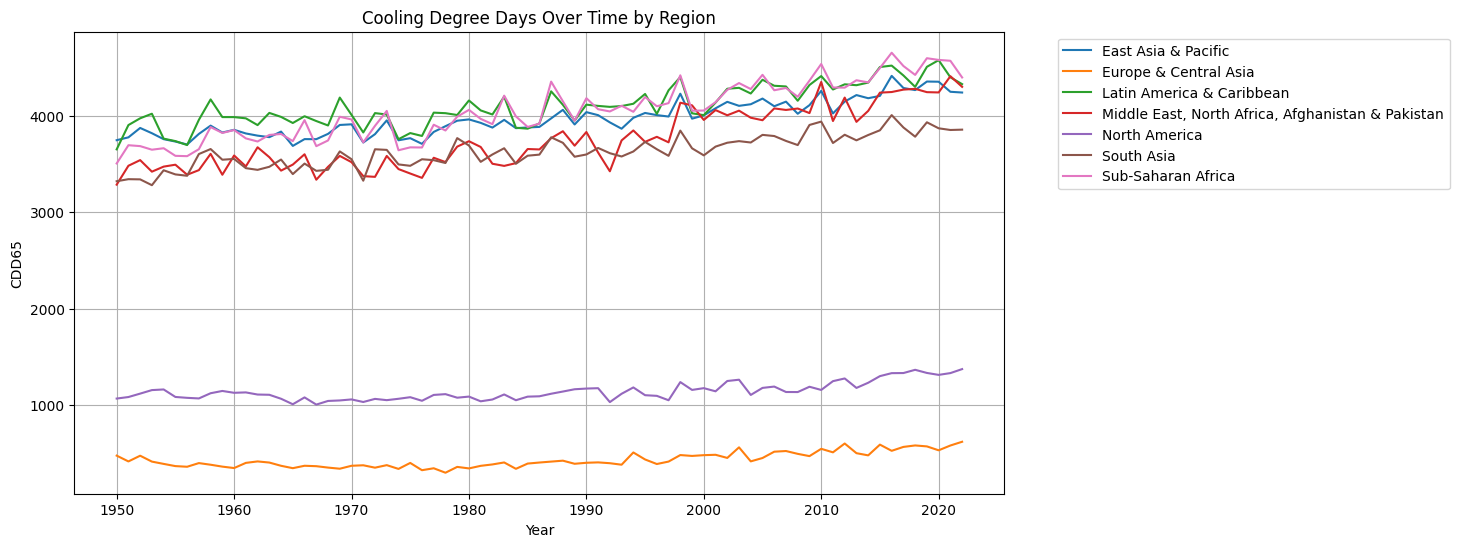

In [14]:
# Drop countries without region info
region_df = cdd_merged.dropna(subset=["region"])

region_trend = region_df.groupby(["region", "year"])["cdd65"].mean().reset_index()

plt.figure(figsize=(12, 6))

for region in region_trend["region"].unique():
    temp = region_trend[region_trend["region"] == region]
    plt.plot(temp["year"], temp["cdd65"], label=region)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Cooling Degree Days Over Time by Region")
plt.xlabel("Year")
plt.ylabel("CDD65")
plt.grid(True)
plt.show()

#### Regional patterns in CDD65

Regional trends reveal strong geographic differences:

- **Sub-Saharan Africa** shows some of the highest CDD values globally, 
consistently above 4,000 and rising further in recent decades.
- **Latin America & Caribbean** and **Middle East, North Africa, Afghanistan & Pakistan** also maintain high levels of heat exposure, all above 3,500–4,000 CDD.
- **South Asia** follows a similar trajectory, with steady increases over time.
- **North America** experiences moderate levels, around 1,000–1,300 CDD, but also shows a gradual upward trend.
- **Europe & Central Asia** is by far the coolest region, remaining between 
250–600 CDD for most of the period, though recent increases are visible.

Overall, hotter regions are getting even hotter, and cooler regions are also warming.  
This widening gap underscores global inequality in heat exposure and the differing 
adaptation challenges regions face.

### 5.3 Trends by income group

Income groups (as defined by the World Bank) provide another useful lens.  
Lower-income countries often face greater vulnerability due to limited 
infrastructure and cooling access.

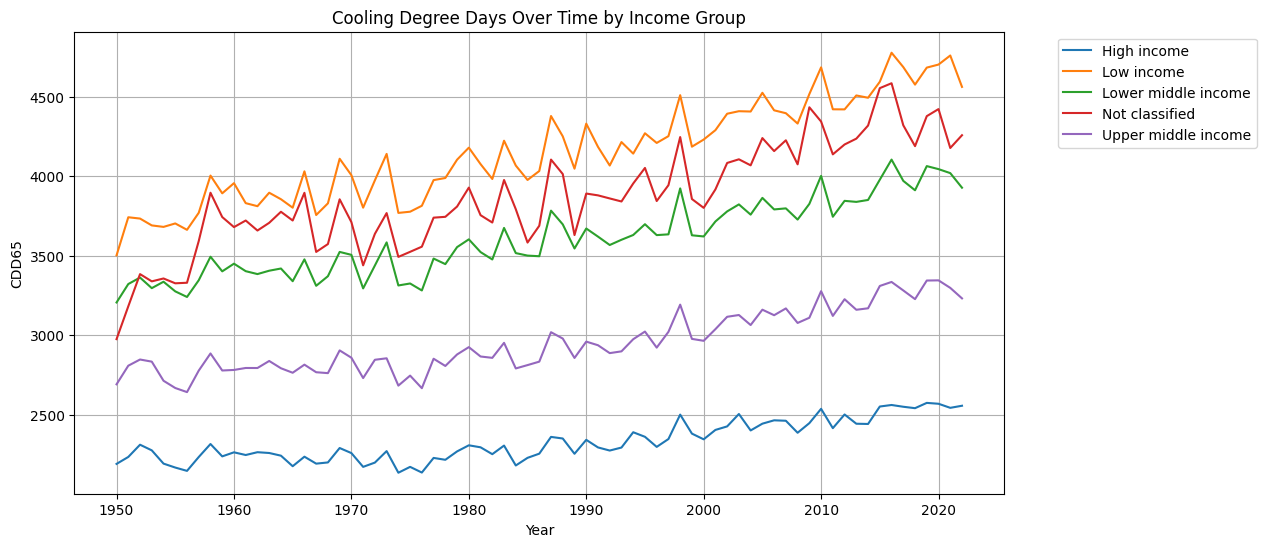

In [15]:
income_df = cdd_merged.dropna(subset=["income_group"])

income_trend = income_df.groupby(["income_group", "year"])["cdd65"].mean().reset_index()

plt.figure(figsize=(12, 6))

for inc in income_trend["income_group"].unique():
    temp = income_trend[income_trend["income_group"] == inc]
    plt.plot(temp["year"], temp["cdd65"], label=inc)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Cooling Degree Days Over Time by Income Group")
plt.xlabel("Year")
plt.ylabel("CDD65")
plt.grid(True)
plt.show()

### Trends by income group

Cooling Degree Days strongly correlate with income levels, reflecting the 
geographic distribution of countries:

- **Low-income countries** show the highest CDD values—often above 4,000 and 
increasing sharply. These countries tend to be located in hotter regions such as 
Sub-Saharan Africa and South Asia.
- **Lower-middle-income countries** also experience substantial heat exposure, 
with values between 3,300–4,000 and rising steadily.
- **Upper-middle-income countries** show moderate heat levels, but with a clear upward trend.
- **High-income countries** are consistently the coolest group, typically in the 
2,200–2,500 range. Their gradual rise still indicates warming, but from a much 
lower baseline.

This divergence highlights an important inequality:  
**countries with the least financial capacity to adapt are exposed to the most intense heat.**

### 5.4 Top and bottom 10 countries in 2022

To understand extremes, I look at the hottest and coolest countries in the most 
recent available year (2022).

In [16]:
latest = cdd_merged[cdd_merged["year"] == 2022].dropna(subset=["country_name"])

top10 = latest.nlargest(10, "cdd65")[["country_name", "cdd65"]]
bottom10 = latest.nsmallest(10, "cdd65")[["country_name", "cdd65"]]

top10, bottom10

(               country_name    cdd65
 17129                  Mali  6995.38
 16998  United Arab Emirates  6978.52
 17174               Senegal  6894.46
 17050              Djibouti  6752.50
 17011          Burkina Faso  6739.48
 17168                 Qatar  6635.55
 17185           South Sudan  6553.23
 17136            Mauritania  6483.88
 17153                  Oman  6456.08
 17108                Kuwait  6418.44,
         country_name  cdd65
 17064  Faroe Islands   0.00
 17078      Greenland   0.00
 17094        Iceland   0.00
 17088    Isle of Man   0.21
 17149         Norway  15.23
 17091        Ireland  20.29
 16997        Andorra  38.19
 17116        Lesotho  43.78
 17114  Liechtenstein  53.22
 17190         Sweden  63.27)

### Hottest and coolest countries in 2022

The hottest countries in 2022 include Mali, UAE, Senegal, Djibouti, Qatar, 
and several others in the Sahel, the Arabian Peninsula, and the Horn of Africa.  
These regions combine desert climates with very high summer temperatures, 
resulting in extreme Cooling Degree Days often exceeding 6,000–7,000.

The coolest countries—such as Greenland, Iceland, Faroe Islands, Norway, 
Ireland, and Sweden—are located in high latitudes or have strong maritime 
influence that moderates summer temperatures. Many have CDD values close to zero.

This contrast highlights the extreme global variation in cooling needs and 
heat exposure. Countries with the highest CDD values often face the greatest 
health risks and the highest energy burden for cooling.

### 5.5 Global choropleth map of Cooling Degree Days (2022)

To visualize geographic patterns, I create a global choropleth map using the most 
recent data (2022). Each country is shaded according to its Cooling Degree Days 
(CDD65), showing how heat exposure varies across the world.

Darker colors indicate higher accumulated heat above 65°F, meaning stronger 
cooling demand and higher heat-related risks.

In [17]:
import plotly.express as px
from IPython.display import HTML

# Use latest year (2022)
latest_year = cdd_merged[cdd_merged["year"] == 2022]

fig = px.choropleth(
    latest_year,
    locations="REF_AREA",  # ISO3 codes
    color="cdd65",  # metric to visualize
    hover_name="country_name",  # tooltip label
    color_continuous_scale="YlOrRd",  # yellow → orange → red
    title="Cooling Degree Days (CDD65) by Country in 2022",
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=False),
    coloraxis_colorbar=dict(title="CDD65", ticksuffix="°F above 65°"),
)

HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

#### Interpretation

The choropleth map clearly highlights global inequalities in heat exposure:

- The **Middle East, North Africa, and the Sahel region** appear in the darkest colors, 
reflecting extremely high CDD values across countries such as Mali, UAE, Qatar, Oman, 
and Senegal.
- **South Asia** (e.g., India, Pakistan) also shows high cooling demand.
- **Tropical regions** in Latin America and Sub-Saharan Africa generally fall into the 
higher CDD bands.
- **Northern Europe, Canada, Greenland, and New Zealand** appear extremely light, 
indicating very low heat accumulation.
- Several island nations and polar regions have near–zero CDD values.

This visualization reinforces earlier findings:  
the countries with the highest heat burden are often those with fewer financial 
resources and greater climate vulnerability.

## Conclusion

Using global Cooling Degree Days (CDD65) data from 1950–2022, this analysis
reveals several consistent and important patterns:

1. **The world is getting hotter.**  
   Global average CDD has increased steadily over the past 70+ years,
   reflecting a clear rise in accumulated heat above 65°F. This implies
   higher cooling demand and greater strain on energy systems worldwide.

2. **Heat exposure is not evenly distributed.**  
   Regions such as Sub-Saharan Africa, Latin America & Caribbean, and the
   Middle East & North Africa consistently experience the highest cooling
   loads, while Europe and other high-latitude areas remain much lower.
   This illustrates strong geographic disparities in climate risk.

3. **Income correlates strongly with heat burden.**  
   Low-income countries have the highest CDD values, followed by
   lower-middle-income countries. High-income countries have the lowest
   heat exposure but still show rising trends.  
   This means **countries with the least adaptive capacity face the
   greatest heat stress** — a key equity concern for climate policy.

4. **Country-level extremes highlight global vulnerability.**  
   The hottest countries include Mali, Senegal, UAE, Qatar, and Djibouti,
   while the coolest include Iceland, Greenland, and Sweden. The contrast
   underscores how different nations face fundamentally different climate
   realities.

Together, these results suggest that cooling demand — and therefore energy use,
infrastructure pressure, and health risks — will continue to rise, especially
in regions least equipped to cope. Understanding these spatial and income-based
patterns is essential for designing equitable and effective climate adaptation
strategies.

## Limitations and Further Work

While the analysis identifies clear global patterns, several limitations should be
noted:

- **CCD65 reflects only one dimension of heat exposure.**  
  It does not capture humidity, nighttime temperatures, heat waves, or local
  microclimate conditions that significantly affect human health.

- **Annual averages may hide important extremes.**  
  Future work could examine seasonal patterns or the frequency of very hot days.

- **Metadata gaps for some small states or territories.**  
  A few countries lacked income or region classifications, which slightly reduces
  completeness for grouped analyses.

- **Socioeconomic impacts were not analyzed here.**  
  For applied policy work, it would be valuable to connect rising CDD to:
  energy access, air conditioning rates, power grid vulnerability,
  and public health outcomes.

- **Spatial visualization could be expanded.**  
  Mapping multiple years or producing animations could provide a richer view of
  how heat exposure spreads over time.

Despite these limitations, the dataset provides a powerful global picture of how
warming trends intersect with development levels. This creates a foundation for
further investigation into climate adaptation and energy resilience.